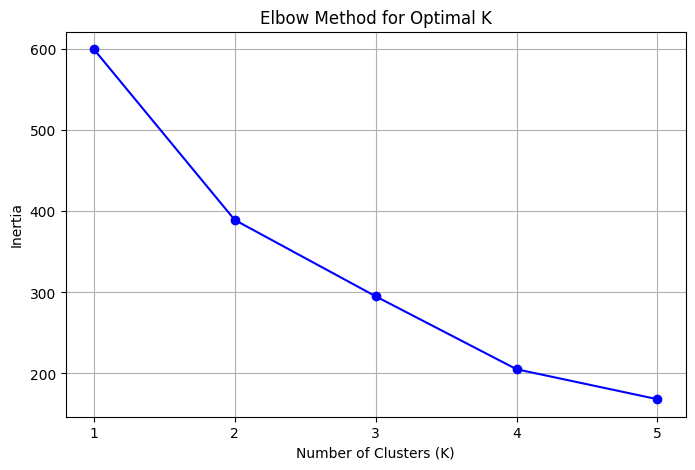

Cluster Characteristics:
         annual_spending  purchase_frequency    age
cluster                                            
0                  26.75               18.35  46.25
1                  41.09               62.24  25.19
2                  86.10               81.53  32.88
3                  86.10               19.36  39.87
4                  54.38               48.85  55.64

Cluster 0 Strategy:
Low-engagement customers: Send personalized re-engagement campaigns.

Cluster 1 Strategy:
Low-engagement customers: Send personalized re-engagement campaigns.

Cluster 2 Strategy:
High-value customers: Offer exclusive promotions and loyalty rewards.

Cluster 3 Strategy:
High-income, lower-spending customers: Provide personalized recommendations and discounts.

Cluster 4 Strategy:
Low-engagement customers: Send personalized re-engagement campaigns.


In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Data source: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

# Load the dataset
df = pd.read_csv("Mall_Customers.csv")

# Rename columns
df = df.rename(columns={
    'Annual Income (k$)': 'annual_spending',
    'Spending Score (1-100)': 'purchase_frequency',
    'Age': 'age'
})

# Preprocess data: Select numerical features and scale them
features = [
    'annual_spending',
    'purchase_frequency',
    'age'
]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine optimal number of clusters using the elbow method
inertia = []
K = range(1, 6)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(K)
plt.grid(True)
plt.savefig('elbow_plot.png')
plt.show()

# Apply K-Means with the selected number of clusters
optimal_k = 5

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df['cluster'] = kmeans.fit_predict(X_scaled)

# Analyze clusters
cluster_summary = (
    df.groupby('cluster')[features]
    .mean()
    .round(2)
)

print("Cluster Characteristics:")
print(cluster_summary)

# Example of targeted strategies
for cluster in sorted(cluster_summary.index):

    spending = cluster_summary.loc[
        cluster,
        'annual_spending'
    ]

    frequency = cluster_summary.loc[
        cluster,
        'purchase_frequency'
    ]

    print(f"\nCluster {cluster} Strategy:")

    if spending >= 70 and frequency >= 70:
        print(
            "High-value customers: Offer exclusive promotions "
            "and loyalty rewards."
        )

    elif spending >= 70 and frequency < 70:
        print(
            "High-income, lower-spending customers: Provide "
            "personalized recommendations and discounts."
        )

    elif spending < 70 and frequency >= 70:
        print(
            "Lower-income, high-spending customers: Offer "
            "affordable bundles and reward programs."
        )

    else:
        print(
            "Low-engagement customers: Send personalized "
            "re-engagement campaigns."
        )

# Save cluster assignments to a CSV file
df.to_csv('customer_segments.csv', index=False)
